<a href="https://colab.research.google.com/github/HunterAlpha7/Real-Risks-Robust-Models-Clear-Insights/blob/main/CatBoost%2BRF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flood Probability Prediction
### Ensemble: Random Forest + CatBoost
Target: `FloodProbability` (continuous 0–1)
- 70% train | 10% validation | 20% test

In [ ]:
!pip install -q catboost
!pip install -q shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

%matplotlib inline
sns.set(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Research/Flood prediction database/flood.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 21)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


Feature Engineering

In [ ]:
# 2. Infrastructure Vulnerability
df['Infrastructure_Vulnerability'] = df[['DamsQuality', 'DrainageSystems', 'DeterioratingInfrastructure', 'RiverManagement']].sum(axis=1)

# 3. Environmental Degradation
df['Environmental_Degradation'] = df[['Deforestation', 'Siltation', 'WetlandLoss', 'Landslides', 'Watersheds']].sum(axis=1)

# 4. Climate / Natural Hazards
df['Climate_Natural_Hazards'] = df[['MonsoonIntensity', 'TopographyDrainage', 'ClimateChange', 'CoastalVulnerability']].sum(axis=1)

# 5. Monsoon vs Drainage Interaction (Higher = Worse Risk for both)
df['Monsoon_Drainage_Interaction'] = df['MonsoonIntensity'] * df['DrainageSystems']

print(f"New Shape after Feature Engineering: {df.shape}")
df.head()


New Shape after Feature Engineering: (50000, 25)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability,Infrastructure_Vulnerability,Environmental_Degradation,Climate_Natural_Hazards,Monsoon_Drainage_Interaction
0,3,8,6,6,4,4,6,2,3,2,...,3,4,3,2,6,0.450,25,17,22,30
1,8,4,5,7,7,9,1,5,5,4,...,1,1,9,1,3,0.475,16,29,23,72
2,3,10,4,1,7,5,4,7,4,9,...,6,1,8,3,6,0.515,21,28,22,21
3,4,4,2,7,3,4,1,4,6,4,...,8,8,6,6,10,0.520,15,29,14,16
4,3,7,5,2,5,8,5,2,7,5,...,3,4,4,3,4,0.475,20,16,24,21


In [ ]:
X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 35000 | Val: 5000 | Test: 10000


In [ ]:
#Initialize the Imputer and Scaler
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

# 2. Fit and transform the TRAINING data
# (Fitting only on the train set prevents data leakage from the test set)
X_train_imputed = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imputed)

# 3. Transform the VALIDATION and TEST data using the rules learned from the train set
X_val_imputed = imputer.transform(X_val)
X_val_scaled = scaler.transform(X_val_imputed)

X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)

# 4. Convert arrays back to DataFrames to preserve column names for feature importance plotting
X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Preprocessing complete: Mean Imputation and Standard Scaling applied successfully!")

Preprocessing complete: Mean Imputation and Standard Scaling applied successfully!


Model defining

In [ ]:
# Random Forest
rf = RandomForestRegressor(n_estimators=600, max_depth=None, random_state=42, n_jobs=-1, warm_start=False)

# CatBoost
cat = CatBoostRegressor(iterations=2500, learning_rate=0.025, depth=8, random_seed=42, verbose=200, loss_function='RMSE', eval_metric='RMSE')

# Define Ensemble
ensemble = VotingRegressor([('rf', rf), ('cat', cat)])

K-Fold

In [ ]:
# Now run the cross validation on the untrained ensemble
cv_r2_scores = cross_val_score(ensemble, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
print(f"Cross-Validation R² Scores: {cv_r2_scores}")

NameError: name 'cross_val_score' is not defined

Model training

In [ ]:
# Train both individual models and the ensemble on the FULL training set
rf.fit(X_train, y_train)
cat.fit(X_train, y_train)
ensemble.fit(X_train, y_train)

print("CatBoost + Random Forest ensemble ready!")


0:	learn: 0.0492416	total: 62ms	remaining: 2m 35s
200:	learn: 0.0091444	total: 3.25s	remaining: 37.2s
400:	learn: 0.0032671	total: 5.83s	remaining: 30.5s
600:	learn: 0.0015597	total: 7.52s	remaining: 23.8s
800:	learn: 0.0010363	total: 9.11s	remaining: 19.3s
1000:	learn: 0.0008595	total: 10.6s	remaining: 15.9s
1200:	learn: 0.0007527	total: 12.2s	remaining: 13.2s
1400:	learn: 0.0006833	total: 13.9s	remaining: 10.9s
1600:	learn: 0.0006284	total: 16s	remaining: 9.01s
1800:	learn: 0.0005839	total: 19.2s	remaining: 7.45s
2000:	learn: 0.0005478	total: 21.4s	remaining: 5.33s
2200:	learn: 0.0005204	total: 23.1s	remaining: 3.14s
2400:	learn: 0.0004953	total: 24.9s	remaining: 1.03s
2499:	learn: 0.0004840	total: 25.8s	remaining: 0us
0:	learn: 0.0492416	total: 16.3ms	remaining: 40.8s
200:	learn: 0.0091444	total: 2.06s	remaining: 23.6s
400:	learn: 0.0032671	total: 4.86s	remaining: 25.4s
600:	learn: 0.0015597	total: 8.08s	remaining: 25.5s
800:	learn: 0.0010363	total: 9.85s	remaining: 20.9s
1000:	lear

### Performance (Expect R² ≥ 0.874)

In [ ]:
y_pred = ensemble.predict(X_test)

print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Test R²   : {r2_score(y_test, y_pred):.6f}")

Test RMSE : 0.008396
Test MAE  : 0.006411
Test R²   : 0.971942


### Classification View (>0.5 = Flood)

### Confusion Matrix

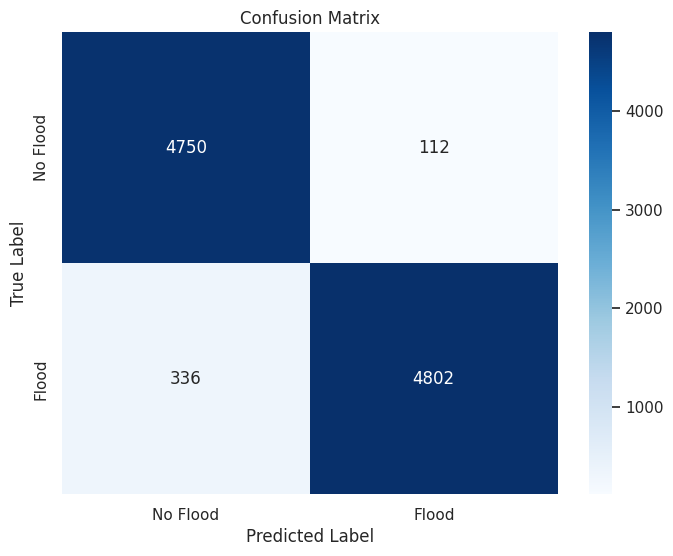

In [ ]:
from sklearn.metrics import confusion_matrix

threshold = 0.5
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

cm = confusion_matrix(y_test_bin, y_pred_bin)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Flood', 'Flood'], yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Accuracy and other stats:

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

threshold = 0.5
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_bin):.5f}")
print(f"F1-Score: {f1_score(y_test_bin, y_pred_bin):.5f}")
print(classification_report(y_test_bin, y_pred_bin, target_names=['No Flood', 'Flood']))

Accuracy: 0.95520
F1-Score: 0.95543
              precision    recall  f1-score   support

    No Flood       0.93      0.98      0.95      4862
       Flood       0.98      0.93      0.96      5138

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



### Plots

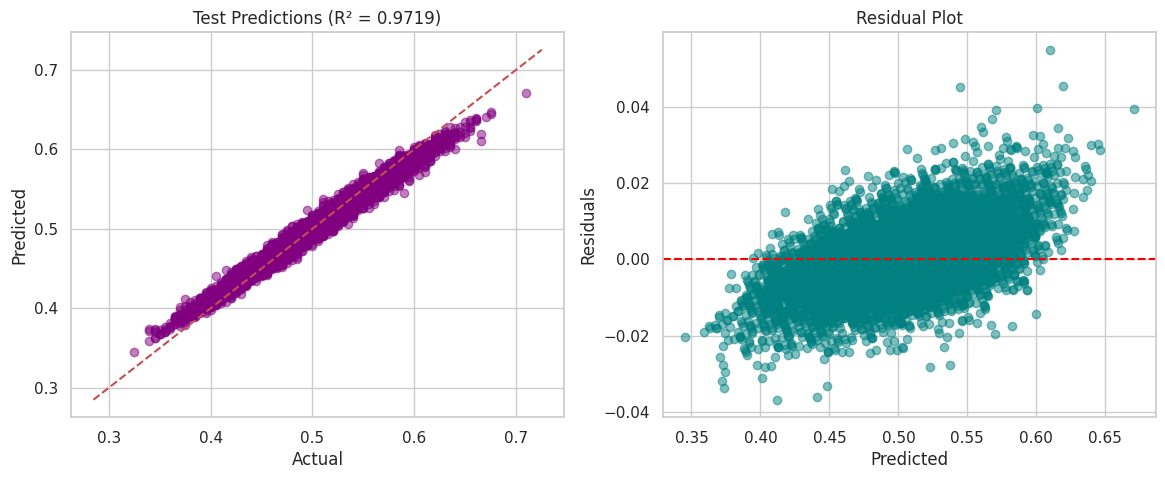

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, y_pred, alpha=0.5, color='purple')
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')
ax[0].set_title(f'Test Predictions (R² = {r2_score(y_test, y_pred):.4f})')

residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.5, color='teal')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residual Plot')

plt.show()

### Feature Importance (from CatBoost)

/tmp/ipykernel_3836/1239418626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[idx], y=feat_names[idx], palette='viridis')


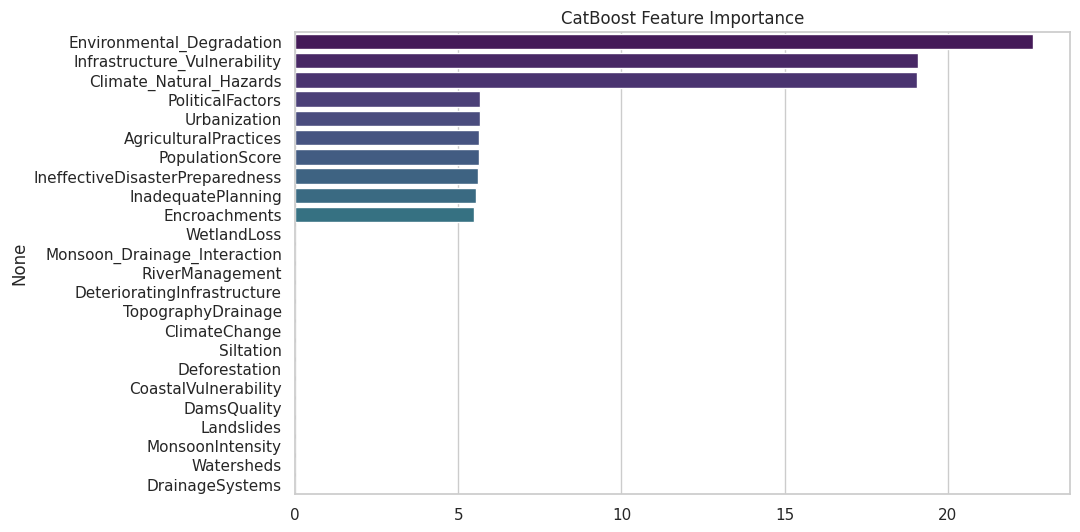

In [ ]:
importances = cat.get_feature_importance()
feat_names = X.columns
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[idx], y=feat_names[idx], palette='viridis')
plt.title('CatBoost Feature Importance')
plt.show()

SHAP implementation

Generating SHAP Explainability Plot...


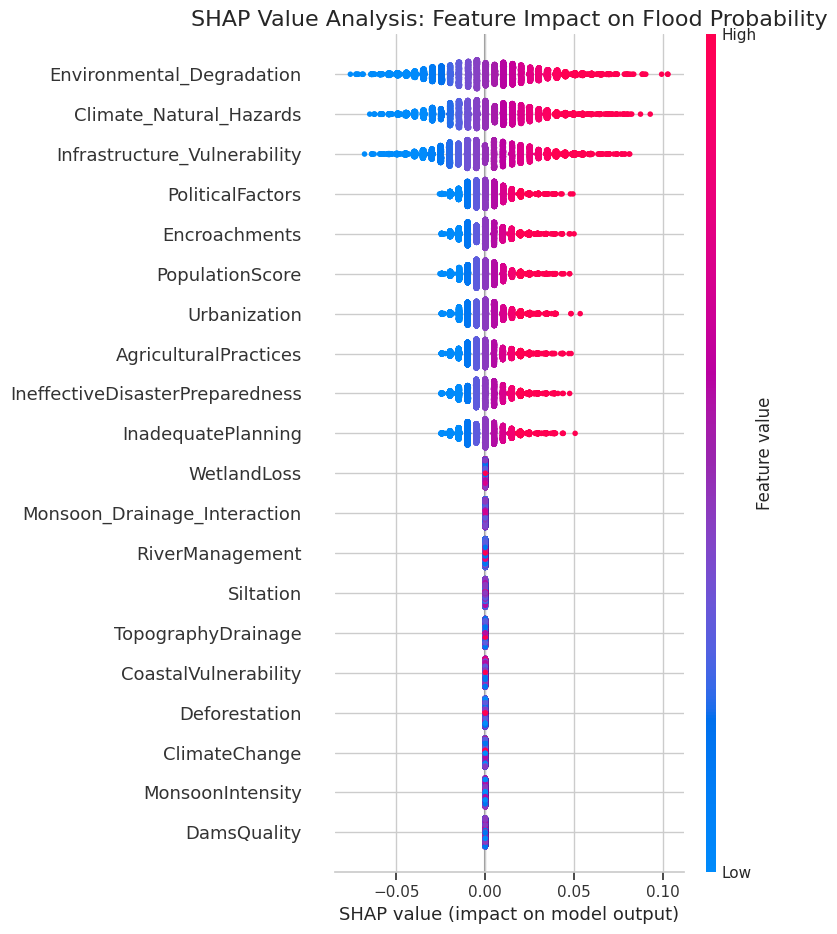

In [ ]:
import shap

print("Generating SHAP Explainability Plot...")

# Initialize the SHAP explainer specifically for the CatBoost model
explainer = shap.TreeExplainer(cat)

# Calculate SHAP values using the test dataset
shap_values = explainer.shap_values(X_test)

# Generate the SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Value Analysis: Feature Impact on Flood Probability", fontsize=16)
plt.tight_layout()
plt.show()

### SHAP Summary Plot (With Engineered Features, Excluding Political Factors)

This plot showcases the impact of the engineered features and original features on the model's predictions, with the `PoliticalFactors` feature completely removed.

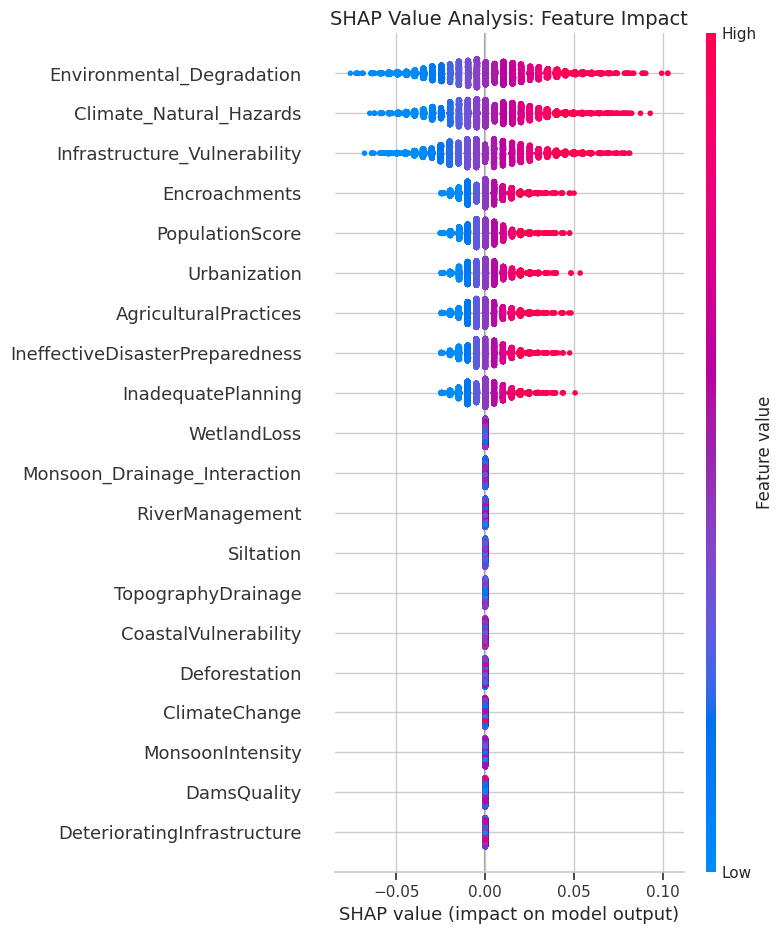

In [ ]:
# 1. Identify all columns except 'PoliticalFactors'
cols_without_political = [col for col in X_test.columns if col != 'PoliticalFactors']

# 2. Get the indices of these columns in the original X_test
col_indices = [X_test.columns.get_loc(col) for col in cols_without_political]

# 3. Filter X_test and shap_values
X_test_filtered = X_test[cols_without_political]
shap_values_filtered = shap_values[:, col_indices]

# 4. Plot the SHAP summary
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_filtered, X_test_filtered, show=False)
plt.title("SHAP Value Analysis: Feature Impact", fontsize=14)
plt.tight_layout()
plt.show()

### SHAP Analysis using Only Original Dataset Features

To analyze the independent impact of only the original dataset features (excluding the engineered compound metrics), we subset our test features to match the original dataset columns and rerun the SHAP summary plot.

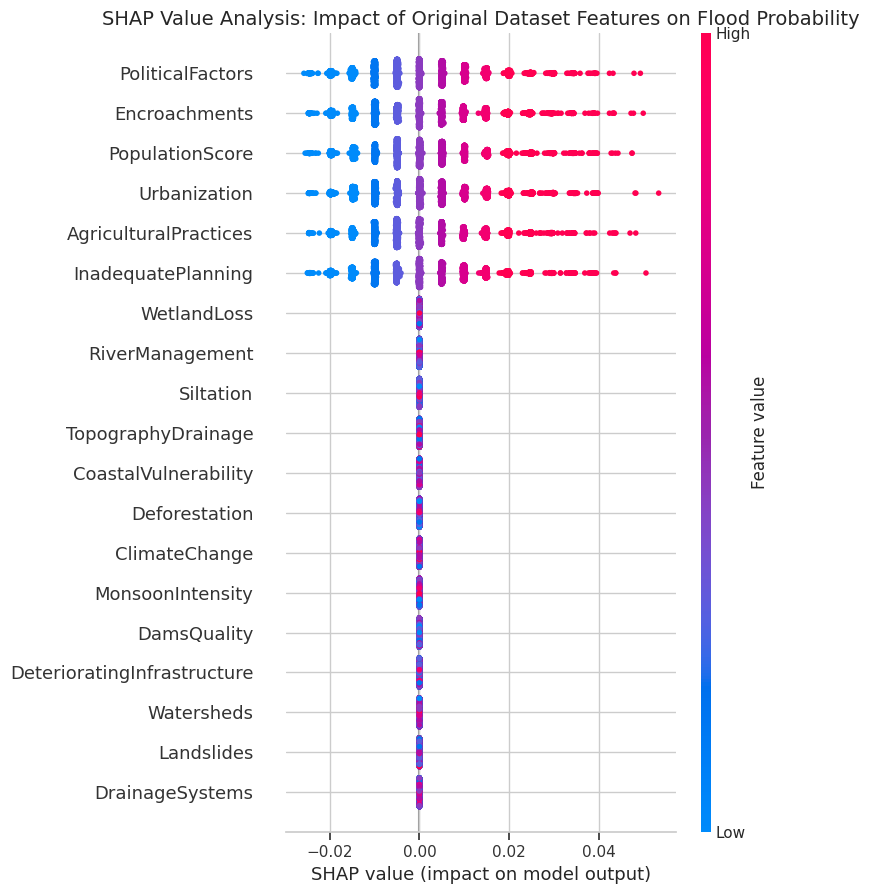

In [ ]:
# 1. Identify the original columns from the initial dataset load
original_cols = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation',
    'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices',
    'Encroachments', 'DrainageSystems', 'CoastalVulnerability', 'Landslides',
    'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
    'InadequatePlanning', 'PoliticalFactors'
]

# 2. Subset the test set and SHAP values to only include these original features
# Retrieve the indices of original columns in X_test
orig_col_indices = [X_test.columns.get_loc(col) for col in original_cols]
X_test_original = X_test[original_cols]
shap_values_original = shap_values[:, orig_col_indices]

# 3. Generate the SHAP Summary Plot for original features only
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_original, X_test_original, show=False)
plt.title("SHAP Value Analysis: Impact of Original Dataset Features on Flood Probability", fontsize=14)
plt.tight_layout()
plt.show()